In [2]:
import pandas as pd

df = pd.read_csv("raceday1_telemetry.csv")
df.head()

,Time,bms.lowest_bank_voltage_*0.1mV.mean,bms.pack_voltage_V.mean,left_mcc.left_mcc_rpm.mean,riedon.riedon_current_mA.mean,right_mcc.right_mcc_rpm.mean,petals.can_pedal_pos.accelPos,petals.can_pedal_pos.brakePos,petals.can_pedal_pos.mechBrake
0,1751562000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1751562001000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1751562002000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1751562003000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1751562004000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.columns = ["time", "vmin_raw", "vpack", "rpm_left", "current_mA",
              "rpm_right", "accel", "brake", "mech_brake"]

In [5]:
df["time"] = (pd.to_datetime(df["time"], unit="ms", utc=True)
              .dt.tz_convert("America/New_York")
              .dt.tz_localize(None))
df = df.set_index("time")

In [6]:
df["vmin"] = df["vmin_raw"] / 10_000
df["current"] = df["current_mA"] / 1000

In [7]:
df[["current", "accel"]].corr()
df["current"] = -df["current"]

In [8]:
bad = ~df["vmin"].between(2.5, 4.3) & df["vmin"].notna()
print(bad.sum(), "glitches removed")
df.loc[bad, "vmin"] = float("nan")

1 glitches removed


<Axes: xlabel='time'>

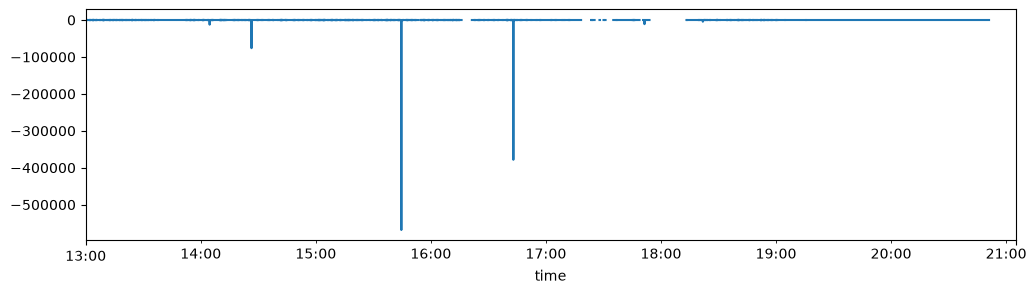

In [9]:
df["current"].plot(figsize=(12, 3))

In [11]:
TIMING_CSV = "FSGP_Electronic_Timing_Day_1.csv"

laps = pd.read_csv(TIMING_CSV, skiprows=3)
laps.columns = ["lap", "start", "finish", "lap_time", "pit_min", "lap_min",
                "official_mph", "driver", "p1", "p2", "p3", "comments"]
laps = laps[["lap", "start", "finish", "pit_min", "official_mph", "driver", "comments"]]
laps.head(20)

,lap,start,finish,pit_min,official_mph,driver,comments
0,1,NaN,10:17:02,NaN,31.615,Evelyn Chuang,NaN
1,2,NaN,10:22:34,0.000,33.614,NaN,NaN
2,3,NaN,10:28:24,0.000,31.886,NaN,NaN
3,4,NaN,10:34:37,0.000,29.920,NaN,NaN
4,5,NaN,10:41:19,0.000,27.761,NaN,NaN
5,6,NaN,10:47:01,0.000,32.632,NaN,NaN
6,7,NaN,10:53:00,0.000,31.086,NaN,NaN
7,8,NaN,10:58:51,0.000,31.795,NaN,NaN
8,9,NaN,11:04:45,0.000,31.525,NaN,NaN
9,10,NaN,11:10:41,0.000,31.348,NaN,NaN
